# Purpose

#### As there is no general analytical expression for volume of a union of spheres, we have to choose some way to integrate these volumes as accurately as possible.
#### The two easiest methods to implement are mesh/grid or monte carlo (MC) integration. There are more advanced methods with better efficiencies, however implementing these methods could be a project in it of itself.
#### Here we benchmark the performance of mesh and MC integration against analytical volumes for the case of single spheres and two-sphere unions, and show which integration method between the two performs better. In addition to the naive pure python implementation of mesh integration, we compare against "pyvolgrid" which utilizes nanobind to link C++ executables to python execution

In [1]:
import numpy as np
from JDFTxFreeNrg.testing import test_double_sphere_volume, test_single_sphere_volume
from JDFTxFreeNrg.testing import test_vcav, test_eff_volume, test_solve_entropy_trans, test_relative_solve_entropy_trans

##### First we test a single sphere volume accuracy.

##### (Note the teal error bars on the MC convergence plot give the 95% confidence interval of the MC simulation)

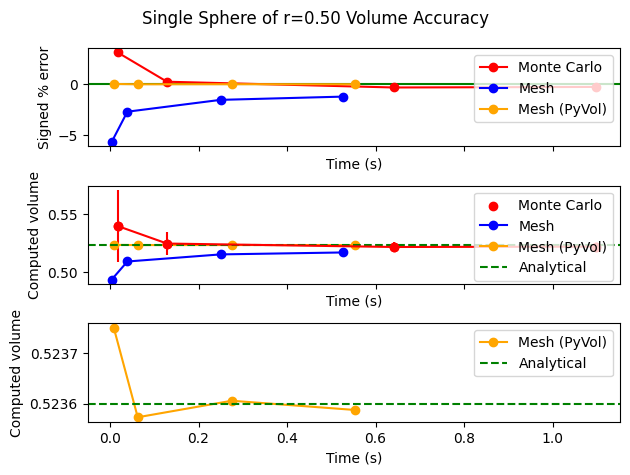

In [3]:
# For this notebook I'm explicitly providing the radii and sphere centers for reproducability.
# Change r/rs/center/centers to None for random generation
r = 0.5
center = np.zeros(3)
mesh_sample_scale = 150 # Since the mesh grid is vectorized, it takes about 150x less time per sample on my machine
nsampless = [1e3, 1e4, 5e4, 1e5]

test_single_sphere_volume(r=r, center=center, mesh_sample_scale=mesh_sample_scale, nsampless=nsampless, pyvol_sample_scale=4000.)

#### And double-sphere volume

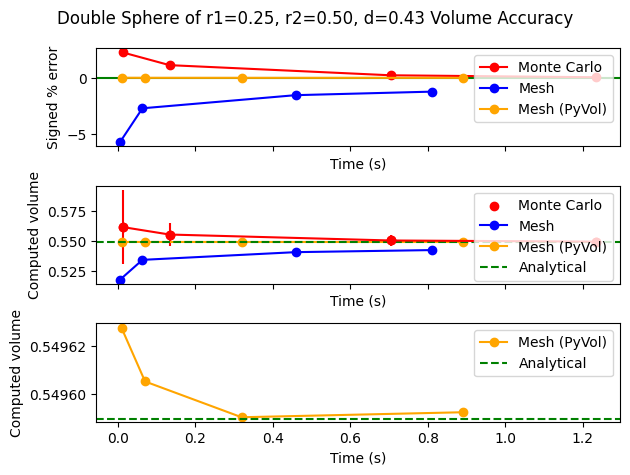

In [4]:
# For this notebook I'm explicitly providing the radii and sphere centers for reproducability.
# Change r/rs/center/centers to None for random generation
rs = [0.25, 0.5]
centers = [np.zeros(3), np.ones(3)*0.25]

test_double_sphere_volume(rs=rs, centers=centers, mesh_sample_scale=mesh_sample_scale, nsampless=nsampless, pyvol_sample_scale=4000.)

#### For both cases we see monte carlo integration outperforms mesh integration in terms of accuracy, but mesh integration is reproducable in its results and is gauranteed to be an enderestimate of the true value. However, pyvolgrid clearly outperforms both by a longshot, needing its own separate graph to show its trend in accuracy w.r.t. computation time.

### Next we test against how important the absolute and relative accuracies are for some important intermediate values and final absolute and relative entropies

In [ ]:
rs_solute = [0.25, 0.5]
centers_solute = [np.zeros(3), np.ones(3)*0.25]

rs_solvent = [0.3]
centers_solvent = [np.zeros(3)]


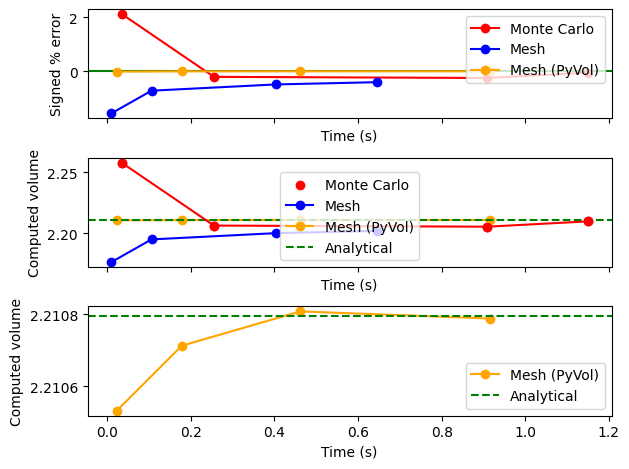

In [6]:
test_vcav(
    solvent_rs=rs_solvent, solvent_centers=centers_solvent, solute_rs=rs_solute, solute_centers=centers_solute,
    pyvol_sample_scale=5000.,
    scale_free_volume=2.0
    )

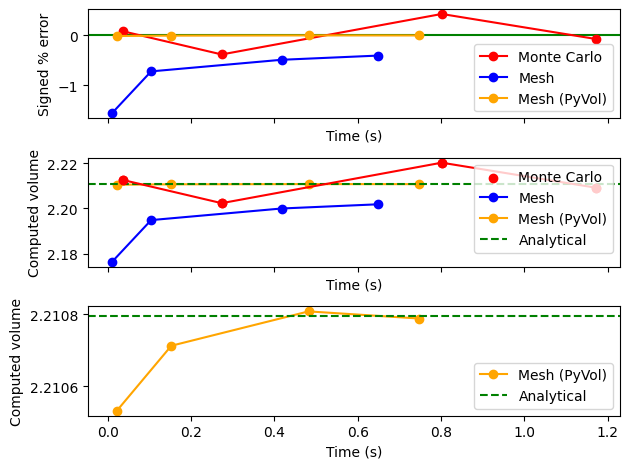

In [10]:
test_eff_volume(
    solvent_rs=rs_solvent, solvent_centers=centers_solvent, solute_rs=rs_solute, solute_centers=centers_solute,
    pyvol_sample_scale=5000.,
    scale_free_volume=2.0
)

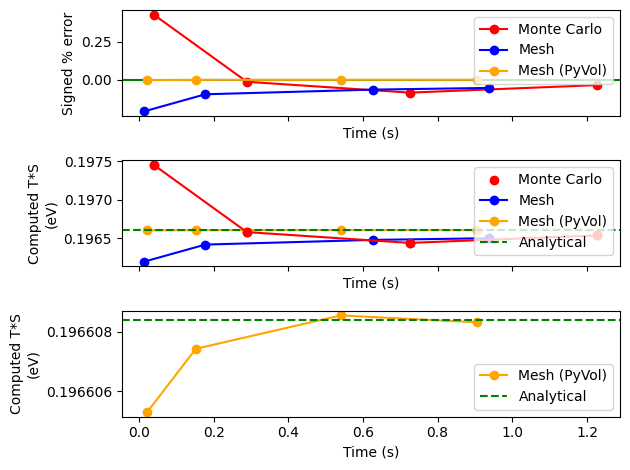

In [6]:
test_solve_entropy_trans(
        solvent_rs=rs_solvent, solvent_centers=centers_solvent, solute_rs=rs_solute, solute_centers=centers_solute,
        pyvol_sample_scale=5000.,
        scale_free_volume=2.0
)

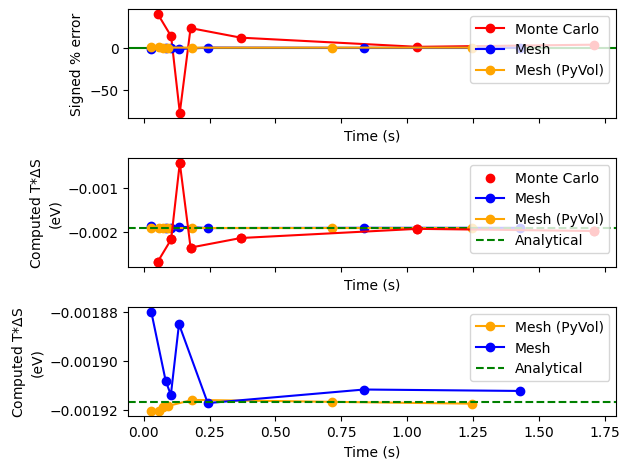

In [2]:
rs_solute1 = [0.25, 0.5]
centers_solute1 = [np.zeros(3), np.ones(3)*0.1]

rs_solute2 = [0.25, 0.5]
centers_solute2 = [np.zeros(3), np.ones(3)*0.65]

rs_solvent = [0.3]
centers_solvent = [np.zeros(3)]

nsampless = [
    1e3, 3e3, 4e3, 5e3, 1e4, 3e4, 5e4,
]

test_relative_solve_entropy_trans(
        solvent_rs=rs_solvent, solvent_centers=centers_solvent,
        solute_rs1=rs_solute1, solute_centers1=centers_solute1,
        solute_rs2=rs_solute2, solute_centers2=centers_solute2,
        pyvol_sample_scale=5000.,
        scale_free_volume=2.0,
        nsampless=nsampless
)

### The final plot represents the most import metric - relative entropies. Although the naive python implementation of mesh integration has been the least consistent for almost all previous benchmarks, since the errors are more consistent, 

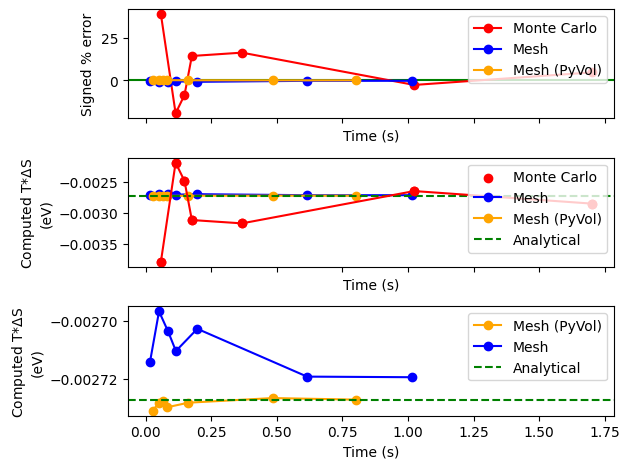

In [3]:
rs_solute1 = [0.5, 0.5]
centers_solute1 = [np.zeros(3), np.ones(3)*0.3]

rs_solute2 = [0.5, 0.5]
centers_solute2 = [np.zeros(3), np.ones(3)*0.65]

rs_solvent = [0.3]
centers_solvent = [np.zeros(3)]

nsampless = [
    1e3, 3e3, 4e3, 5e3, 1e4, 3e4, 5e4,
]

test_relative_solve_entropy_trans(
        solvent_rs=rs_solvent, solvent_centers=centers_solvent,
        solute_rs1=rs_solute1, solute_centers1=centers_solute1,
        solute_rs2=rs_solute2, solute_centers2=centers_solute2,
        pyvol_sample_scale=5000.,
        scale_free_volume=2.0,
        nsampless=nsampless
)